In [1]:
print("hello world")

hello world


# test Env

In [2]:
import sys
import platform
import torch


print("HASTIKA ENVIRONMENT CHECK")



print(f"Python version : {platform.python_version()}")
print(f"Python path    : {sys.executable}")

print(f"\nPyTorch version: {torch.__version__}")

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"CUDA version   : {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"GPU count      : {torch.cuda.device_count()}")
else:
    print("GPU            : Not available")



HASTIKA ENVIRONMENT CHECK
Python version : 3.11.9
Python path    : S:\4.2\bangla\Hastika-ICON2026\.venv\Scripts\python.exe

PyTorch version: 2.11.0+cu128
CUDA available : True
CUDA version   : 12.8
GPU            : NVIDIA GeForce RTX 3050 Laptop GPU
GPU count      : 1


# load datasets

In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

# Task A: Binary classification
binary_train = pd.read_csv(DATA_DIR / "binary_train.csv")
binary_val = pd.read_csv(DATA_DIR / "binary_validation_inputs.csv")

# Task B: Multiclass classification
multiclass_train = pd.read_csv(DATA_DIR / "multiclass_train.csv")
multiclass_val = pd.read_csv(DATA_DIR / "multiclass_validation_inputs.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
# check the data sets

print("Binary Training Data      :", binary_train.shape)
print("Binary Validation Data    :", binary_val.shape)
print("Multiclass Training Data  :", multiclass_train.shape)
print("Multiclass Validation Data:", multiclass_val.shape)

Binary Training Data      : (6446, 3)
Binary Validation Data    : (806, 2)
Multiclass Training Data  : (3159, 3)
Multiclass Validation Data: (395, 2)


In [5]:
print("TASK A — Binary Training")
display(binary_train.head())

print("\nTASK B — Multiclass Training")
display(multiclass_train.head())

TASK A — Binary Training


,id,Comment,Label
0,7417,Mir.Amarprasad nimage dhairya iddalli Sri raji...,Non-Hate
1,1549,"amar sir , à²à³à²¹à³à²²à²¿ Bad performance,...",Non-Hate
2,5944,yarige bekittu inthadella avar hatra en ide bo...,Hate
3,7700,Ara hu cha evanu aa taliban mmaat keli illi ba...,Hate
4,1293,Enu boss bartha bartha hero kale kami agthide,Hate



TASK B — Multiclass Training


,id,Comment,Hate Category
0,958,Bajetigu odalikke takarau maduvashtu vyavadana...,Political
1,4693,Unnata shikshana sachivanaagi Tippu bagge apap...,Political
2,2194,Ivlu papa avr ammage respect kodalla inn mugit...,Gender
3,3073,Nin english illi yeno ankonde adre big boss al...,Gender
4,1801,intha ugrarannu support maduva namma kelavobba...,Violence


In [6]:
print("Binary train columns     :", binary_train.columns.tolist())
print("Binary validation columns:", binary_val.columns.tolist())
print("Multiclass train columns :", multiclass_train.columns.tolist())
print("Multiclass validation    :", multiclass_val.columns.tolist())

Binary train columns     : ['id', 'Comment', 'Label']
Binary validation columns: ['id', 'Comment']
Multiclass train columns : ['id', 'Comment', 'Hate Category']
Multiclass validation    : ['id', 'Comment']


# check text encoding

In [13]:
import pandas as pd
import re

def check_text_encoding(df, text_col="Comment", sample_size=10):
    texts = df[text_col].dropna().astype(str)

    # Common signs of UTF-8 decoded incorrectly as Latin-1/Windows-1252
    mojibake_pattern = re.compile(r"(à[^\s]{0,3}|â[^\s]{0,3}|ð[^\s]{0,3}|Ã[^\s]{0,3})")

    mojibake_count = 0
    replacement_count = 0
    kannada_count = 0
    non_ascii_count = 0

    for text in texts:
        if mojibake_pattern.search(text):
            mojibake_count += 1

        if "\ufffd" in text:
            replacement_count += 1

        if any("\u0c80" <= c <= "\u0cff" for c in text):
            kannada_count += 1

        if any(ord(c) > 127 for c in text):
            non_ascii_count += 1

    print("=" * 60)
    print("TEXT ENCODING CHECK")
    print("=" * 60)

    print(f"Total comments checked : {len(texts):,}")
    print(f"Non-ASCII comments     : {non_ascii_count:,}")
    print(f"Kannada comments       : {kannada_count:,}")
    print(f"Mojibake detected      : {mojibake_count:,}")
    print(f"Replacement chars (?)  : {replacement_count:,}")

    print("\n--- Sample comments ---")

    for i, text in enumerate(texts.head(sample_size)):
        print(f"\n[{i}] {text}")

    print("\n--- Encoding diagnosis ---")

    if replacement_count > 0:
        print("Replacement characters (?) detected.")
        print("Some characters may already be irreversibly corrupted.")

    elif mojibake_count > 0:
        print("POSSIBLE ENCODING PROBLEM DETECTED.")
        print("Patterns such as 'à²', 'à³', 'Ã', 'â' or 'ð' were found.")
        print("This commonly indicates UTF-8 text decoded using the wrong encoding.")

    elif kannada_count > 0:
        print("Kannada Unicode characters detected correctly.")
        print("No obvious mojibake pattern detected.")

    else:
        print("No Kannada Unicode characters detected in the sample.")
        print("The dataset may contain mostly Romanized Kannada/English.")

    print("=" * 60)


# Task A
print("TASK A")
check_text_encoding(binary_train)

# Task B
print("\nTASK B")
check_text_encoding(multiclass_train)

TASK A
TEXT ENCODING CHECK
Total comments checked : 6,446
Non-ASCII comments     : 1,016
Kannada comments       : 0
Mojibake detected      : 1,003
Replacement chars (?)  : 0

--- Sample comments ---

[0] Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi

[1] amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

[2] yarige bekittu inthadella avar hatra en ide bomb irbek ashte

[3] Ara hu cha evanu aa taliban mmaat keli illi banidane

[4] Enu boss bartha bartha hero kale kami agthide

[5] Chaple thagond hodire e sulle ge

[6] Ninu antavle bidu. Tayianthe maglu. Honnayakanahalli li ninu dodda dagar antha modle elargu gothu

[7] Le dummi anchor batte bichi torsodu sadane na..

[8] Dagar mundevu

[9] Avana name haenu antha ghotthaglilla avani sulae maga avara Amma nijavagalu ibbanae appa Amma Hilla aa qurel man  beverci alkat thoo avana mukakkae yava partiyavaru  avanannu gallig

In [9]:
def fix_mojibake(text):
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


# Test on a few affected comments
for i in [1, 3, 7]:
    original = binary_train.loc[i, "Comment"]
    fixed = fix_mojibake(original)

    print("=" * 70)
    print("ORIGINAL:")
    print(original)
    print("\nFIXED:")
    print(fixed)

ORIGINAL:
amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

FIXED:
amar sir , ಕೊಹ್ಲಿ Bad performance, eshto world best players ನ Best performance.<br> &quot; Level of KING KOHLI 💪
ORIGINAL:
Ara hu cha evanu aa taliban mmaat keli illi banidane

FIXED:
Ara hu cha evanu aa taliban mmaat keli illi banidane
ORIGINAL:
Le dummi anchor batte bichi torsodu sadane na..

FIXED:
Le dummi anchor batte bichi torsodu sadane na..


In [14]:
def fix_mojibake(text):
    try:
        return text.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return text


# Create corrected text columns
binary_train["Comment_clean"] = binary_train["Comment"].apply(fix_mojibake)
binary_val["Comment_clean"] = binary_val["Comment"].apply(fix_mojibake)

multiclass_train["Comment_clean"] = multiclass_train["Comment"].apply(fix_mojibake)
multiclass_val["Comment_clean"] = multiclass_val["Comment"].apply(fix_mojibake)

print("Encoding correction completed.")

Encoding correction completed.


In [15]:
def encoding_summary(df, name):
    original_mojibake = df["Comment"].astype(str).str.contains(
        r"à|â|ð|Ã", regex=True
    ).sum()

    cleaned_kannada = df["Comment_clean"].astype(str).apply(
        lambda x: any("\u0c80" <= c <= "\u0cff" for c in x)
    ).sum()

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Rows                    : {len(df):,}")
    print(f"Original mojibake       : {original_mojibake:,}")
    print(f"Cleaned Kannada text    : {cleaned_kannada:,}")


encoding_summary(binary_train, "Binary Training")
encoding_summary(binary_val, "Binary Validation")
encoding_summary(multiclass_train, "Multiclass Training")
encoding_summary(multiclass_val, "Multiclass Validation")

Binary Training
Rows                    : 6,446
Original mojibake       : 1,003
Cleaned Kannada text    : 45
Binary Validation
Rows                    : 806
Original mojibake       : 138
Cleaned Kannada text    : 4
Multiclass Training
Rows                    : 3,159
Original mojibake       : 213
Cleaned Kannada text    : 4
Multiclass Validation
Rows                    : 395
Original mojibake       : 22
Cleaned Kannada text    : 2


In [16]:
print("\nSample corrected comments:\n")

for i in range(10):
    if binary_train.loc[i, "Comment"] != binary_train.loc[i, "Comment_clean"]:
        print("ORIGINAL:")
        print(binary_train.loc[i, "Comment"])
        print("\nCORRECTED:")
        print(binary_train.loc[i, "Comment_clean"])
        print("\n" + "-" * 70)


Sample corrected comments:

ORIGINAL:
amar sir , à²à³à²¹à³à²²à²¿ Bad performance, eshto world best players à²¨ Best performance.<br> &quot; Level of KING KOHLI ðª

CORRECTED:
amar sir , ಕೊಹ್ಲಿ Bad performance, eshto world best players ನ Best performance.<br> &quot; Level of KING KOHLI 💪

----------------------------------------------------------------------


# data inspection

In [17]:
# Dataset quality inspection

datasets = {
    "Binary Train": binary_train,
    "Binary Validation": binary_val,
    "Multiclass Train": multiclass_train,
    "Multiclass Validation": multiclass_val
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    print("Shape:", df.shape)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())
    print("Duplicate comments:", df["Comment_clean"].duplicated().sum())

    if "Label" in df.columns:
        print("\nLabels:")
        print(df["Label"].value_counts())

    if "Hate Category" in df.columns:
        print("\nHate Categories:")
        print(df["Hate Category"].value_counts())

    print()

Binary Train
Shape: (6446, 4)

Missing values:
id               0
Comment          0
Label            0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 37

Labels:
Label
Non-Hate    3286
Hate        3160
Name: count, dtype: int64

Binary Validation
Shape: (806, 3)

Missing values:
id               0
Comment          0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 0

Multiclass Train
Shape: (3159, 4)

Missing values:
id               0
Comment          0
Hate Category    0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 13

Hate Categories:
Hate Category
Gender           1362
Political         559
Others            449
Religion          382
Violence          221
Geo-political     186
Name: count, dtype: int64

Multiclass Validation
Shape: (395, 3)

Missing values:
id               0
Comment          0
Comment_clean    0
dtype: int64

Duplicate rows: 0
Duplicate comments: 0



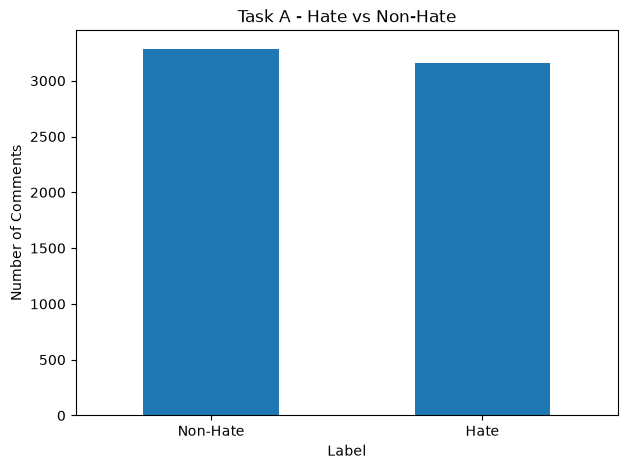

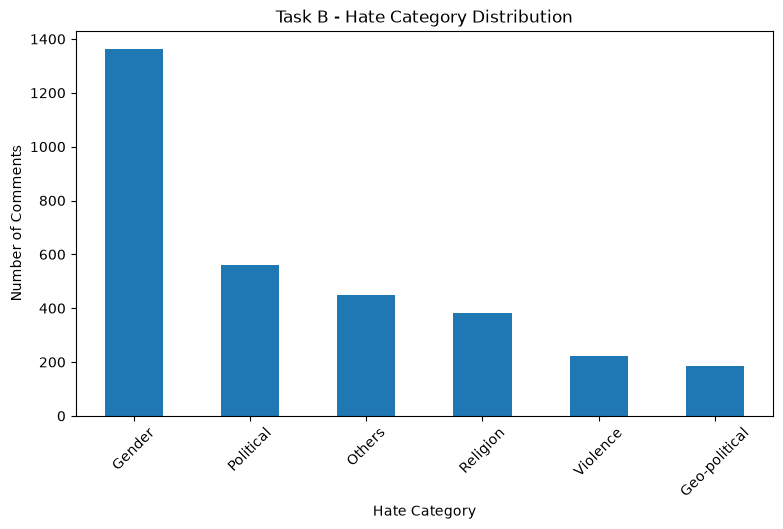

In [18]:
import matplotlib.pyplot as plt

# Task A
plt.figure(figsize=(7, 5))
binary_train["Label"].value_counts().plot(kind="bar")
plt.title("Task A - Hate vs Non-Hate")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()


# Task B
plt.figure(figsize=(9, 5))
multiclass_train["Hate Category"].value_counts().plot(kind="bar")
plt.title("Task B - Hate Category Distribution")
plt.xlabel("Hate Category")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

# comment length analysis

In [19]:
# Comment length analysis

for df in [binary_train, multiclass_train]:
    df["char_length"] = df["Comment_clean"].str.len()
    df["word_count"] = df["Comment_clean"].str.split().str.len()


print("=" * 60)
print("TASK A - BINARY TRAIN")
print("=" * 60)

print(binary_train[["char_length", "word_count"]].describe())


print("\n" + "=" * 60)
print("TASK B - MULTICLASS TRAIN")
print("=" * 60)

print(multiclass_train[["char_length", "word_count"]].describe())

TASK A - BINARY TRAIN
       char_length   word_count
count  6446.000000  6446.000000
mean     74.725411    11.095098
std      76.173411    10.757534
min       5.000000     1.000000
25%      32.000000     5.000000
50%      52.000000     8.000000
75%      89.000000    13.000000
max    1084.000000   136.000000

TASK B - MULTICLASS TRAIN
       char_length   word_count
count  3159.000000  3159.000000
mean     87.047800    12.714783
std      82.622162    11.688077
min       7.000000     1.000000
25%      38.000000     6.000000
50%      61.000000     9.000000
75%     106.000000    15.000000
max     875.000000   128.000000


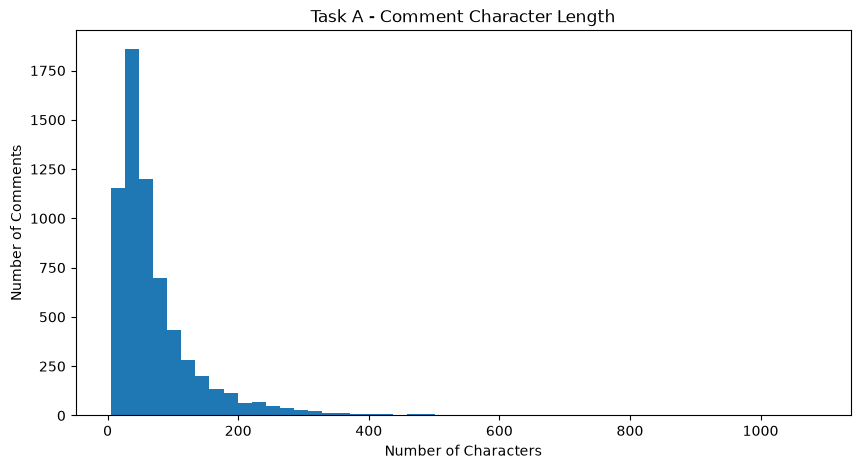

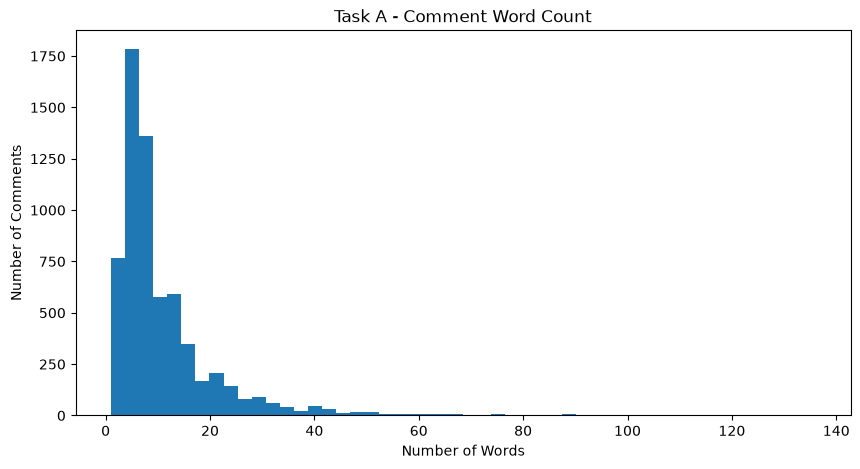

In [20]:
# Character length distribution

plt.figure(figsize=(10, 5))
plt.hist(binary_train["char_length"], bins=50)
plt.title("Task A - Comment Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")
plt.show()


# Word count distribution

plt.figure(figsize=(10, 5))
plt.hist(binary_train["word_count"], bins=50)
plt.title("Task A - Comment Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.show()

In [21]:
# Check duplicate comments and their labels

print("=" * 70)
print("TASK A - DUPLICATE COMMENTS")
print("=" * 70)

duplicates_a = binary_train[
    binary_train["Comment_clean"].duplicated(keep=False)
].sort_values("Comment_clean")

display(duplicates_a[["Comment_clean", "Label"]])


print("\n" + "=" * 70)
print("TASK B - DUPLICATE COMMENTS")
print("=" * 70)

duplicates_b = multiclass_train[
    multiclass_train["Comment_clean"].duplicated(keep=False)
].sort_values("Comment_clean")

display(duplicates_b[["Comment_clean", "Hate Category"]])

TASK A - DUPLICATE COMMENTS


,Comment_clean,Label
4636,nim moun tulla randi magan,Hate
6149,nim moun tulla randi magan,Hate
2985,700 koti rajyada papulation?,Non-Hate
5179,700 koti rajyada papulation?,Non-Hate
4158,A hengadina miukha didare nachike agutte nama...,Hate
...,...,...
2806,"Swami , avaga yav govt ittu annodu heltiyalla....",Hate
2191,Yenne Congress Party Muduka😂😂😂😂😂😂👍,Hate
4390,Yenne Congress Party Muduka😂😂😂😂😂😂👍,Hate
5377,yena.rajakarnigalu..YEKVACHANADLI.MATHDTHI...A...,Hate



TASK B - DUPLICATE COMMENTS


,Comment_clean,Hate Category
1631,nim moun tulla randi magan,Gender
1751,nim moun tulla randi magan,Gender
396,Boli Maga na ninu csk fan na,Gender
1001,Boli Maga na ninu csk fan na,Gender
243,Dagar dagar dam dam dagar dagar sule ??,Gender
2636,Dagar dagar dam dam dagar dagar sule ??,Gender
1123,Dagar sonu,Gender
1135,Dagar sonu,Gender
2972,Dagar sonu,Gender
1801,Ivane dodda kala ivanu hatra hogi question kel...,Others


In [22]:
# Find duplicate comments with conflicting labels/categories

print("=" * 70)
print("TASK A - CONFLICTING DUPLICATES")
print("=" * 70)

conflicts_a = (
    binary_train.groupby("Comment_clean")["Label"]
    .nunique()
)

conflicts_a = conflicts_a[conflicts_a > 1]

print("Number of conflicting comments:", len(conflicts_a))


print("\n" + "=" * 70)
print("TASK B - CONFLICTING DUPLICATES")
print("=" * 70)

conflicts_b = (
    multiclass_train.groupby("Comment_clean")["Hate Category"]
    .nunique()
)

conflicts_b = conflicts_b[conflicts_b > 1]

print("Number of conflicting comments:", len(conflicts_b))

TASK A - CONFLICTING DUPLICATES
Number of conflicting comments: 3

TASK B - CONFLICTING DUPLICATES
Number of conflicting comments: 2


In [23]:
# Display all conflicting duplicate comments

print("=" * 70)
print("TASK A - CONFLICTING DUPLICATES")
print("=" * 70)

conflict_comments_a = (
    binary_train.groupby("Comment_clean")["Label"]
    .nunique()
)

conflict_comments_a = conflict_comments_a[
    conflict_comments_a > 1
].index

display(
    binary_train[
        binary_train["Comment_clean"].isin(conflict_comments_a)
    ][["Comment_clean", "Label"]]
    .sort_values("Comment_clean")
)


print("\n" + "=" * 70)
print("TASK B - CONFLICTING DUPLICATES")
print("=" * 70)

conflict_comments_b = (
    multiclass_train.groupby("Comment_clean")["Hate Category"]
    .nunique()
)

conflict_comments_b = conflict_comments_b[
    conflict_comments_b > 1
].index

display(
    multiclass_train[
        multiclass_train["Comment_clean"].isin(conflict_comments_b)
    ][["Comment_clean", "Hate Category"]]
    .sort_values("Comment_clean")
)

TASK A - CONFLICTING DUPLICATES


,Comment_clean,Label
5924,Ella cm thara evaru adjust aagilla adkke...,Hate
5970,Ella cm thara evaru adjust aagilla adkke...,Non-Hate
184,Ivanu jail inda bandaga en madidda gottillva n...,Hate
2644,Ivanu jail inda bandaga en madidda gottillva n...,Non-Hate
1124,Kangres gorment barbeku sidramyyasar cmagbeku ...,Hate
4121,Kangres gorment barbeku sidramyyasar cmagbeku ...,Non-Hate



TASK B - CONFLICTING DUPLICATES


,Comment_clean,Hate Category
582,Ninuna jilige hakidre desha rajyake nemdi ...,Geo-political
2287,Ninuna jilige hakidre desha rajyake nemdi ...,Political
108,Surprise enuo ellappa edhella namma janru madk...,Geo-political
248,Surprise enuo ellappa edhella namma janru madk...,Others


In [24]:
# Sample comments from each Task A class

print("=" * 70)
print("TASK A - SAMPLE COMMENTS")
print("=" * 70)

for label in ["Hate", "Non-Hate"]:
    print("\n" + "-" * 70)
    print(label)
    print("-" * 70)

    samples = binary_train[
        binary_train["Label"] == label
    ]["Comment_clean"].sample(
        n=10,
        random_state=42
    )

    for i, comment in enumerate(samples, 1):
        print(f"{i}. {comment}")

TASK A - SAMPLE COMMENTS

----------------------------------------------------------------------
Hate
----------------------------------------------------------------------
1. Entha avurunu yaru interview madala
2. @Seenu N le appi hogi maneli amma yendru madirthare tindubittu uchhe uyyidubittu malko ogu aste nin jeevana😂
3. Leee bevarsi nimkinta aa madrasi gale eshto vasi
4. Innentha math adtare nim antha backet hidkond views goskara thu nim makke
5. Innenu Intha kitthodhor na akondre disrespect bittre innen expect madthira? Ah ibbru lowdas name gothilla.. short hair girl and curly hair guy noduddhre mai mai mutkondu asayyadh chutiyas thara adthare. This is freaking family show where public audiences expects friendship, respect and manners. But this ott has none of these. Tv news chutiyagalge olle TRP and useless content. SUDEEP SIR ANTHU SONU GE CHAPPALI LI ODDHANG HELUDDHRU AVL MOKA NAYI HEL THINDHIRO THARA AGIDHE 😂🔥
6. Sule inu eshtu janaranna kondidalo
7. Nehru the true villan of 

In [25]:
# Sample comments from each Task B category

print("=" * 70)
print("TASK B - SAMPLE COMMENTS")
print("=" * 70)

categories = [
    "Gender",
    "Political",
    "Religion",
    "Geo-political",
    "Violence",
    "Others"
]

for category in categories:
    print("\n" + "-" * 70)
    print(category)
    print("-" * 70)

    samples = multiclass_train[
        multiclass_train["Hate Category"] == category
    ]["Comment_clean"].sample(
        n=min(10, len(multiclass_train[
            multiclass_train["Hate Category"] == category
        ])),
        random_state=42
    )

    for i, comment in enumerate(samples, 1):
        print(f"{i}. {comment}")

TASK B - SAMPLE COMMENTS

----------------------------------------------------------------------
Gender
----------------------------------------------------------------------
1. Mooru bittoru urge doddoru ?? ural yar yen helidru care madalla ee dove rani????????
2. Mostly ee btv  sonu relative avr channel ansutte???? adeng ivlna oglutare sadane sadane anta,oo god, channel avrge maryade idiya ,en kit dabakidald aa sonu , yav seeme celebrity avlu aa
3. Le lowdy siddu nin Sacha sule maga
4. Nin amma paapa kane yake lovede nin ammange value kodo soolemunde avra yedhurgadene kaal mele haaki  kari thullu thoristha idhiyalla thuu
5. Ivnyaro sule maga
6. Sonu matadod nodudre Tika ella uriyutte olle chaild tara adtale
7. No 1 dagar in Asia
8. Sule munde nA kyakarsi hugthu hatti avla ache ge
9. Sania mirza muradabad ppakistani loafer lady Jai kannada jai Karnataka ivalu tulli
10. Dagar dagar avl???? idu bittu bere  enilla

----------------------------------------------------------------------
Po

In [26]:
import html
import re

def clean_text(text):
    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


binary_train["text"] = binary_train["Comment_clean"].apply(clean_text)
binary_val["text"] = binary_val["Comment_clean"].apply(clean_text)

multiclass_train["text"] = multiclass_train["Comment_clean"].apply(clean_text)
multiclass_val["text"] = multiclass_val["Comment_clean"].apply(clean_text)

print("Text cleaning completed.")

Text cleaning completed.


In [27]:
print(binary_train["text"].iloc[0])

Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi


In [28]:
import html
import re

def clean_text(text):
    # Decode HTML entities
    text = html.unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


binary_train["text"] = binary_train["Comment_clean"].apply(clean_text)
binary_val["text"] = binary_val["Comment_clean"].apply(clean_text)

multiclass_train["text"] = multiclass_train["Comment_clean"].apply(clean_text)
multiclass_val["text"] = multiclass_val["Comment_clean"].apply(clean_text)

print("Text preprocessing completed.")

Text preprocessing completed.


In [30]:
print("Original:")
print(binary_train["Comment_clean"].iloc[0])

print("\nCleaned:")
print(binary_train["text"].iloc[0])

Original:
Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi

Cleaned:
Mir.Amarprasad nimage dhairya iddalli Sri rajiv dixit ravara kurithagi ondu video madi
